In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# настройки pandas для удобного отображения данных
pd.set_option('display.max_colwidth', None)  # Показывать всю длину текста в столбце
pd.set_option('display.width', 150)         # Общая ширина вывода
# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

from pyproj import Geod
GEOD = Geod(ellps="WGS84")

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split

# импортируем библиотеки для преобразований признаков
from scipy import stats

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sf-booking/hotels_test.csv
/kaggle/input/sf-booking/hotels_train.csv
/kaggle/input/sf-booking/submission.csv


In [2]:
# зафиксируем RANDOM_SEED, чтобы эксперименты были воспроизводимы
RANDOM_SEED = 42

In [3]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

## Загрузка данных: train/test + submission

In [4]:
# Подгрузим наши данные из соревнования

DATA_DIR = '/kaggle/input/sf-booking/'
df_train = pd.read_csv(DATA_DIR+'/hotels_train.csv') # датасет для обучения
df_test = pd.read_csv(DATA_DIR+'hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv(DATA_DIR+'/submission.csv') # самбмишн

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("Sample shape:", sample_submission.shape)

Train shape: (386803, 17)
Test shape: (128935, 16)
Sample shape: (128935, 2)


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [6]:
df_train.sample(5)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
346970,4 Rue La Boetie 8th arr 75008 Paris France,81,12/12/2016,8.7,Hotel Park Lane Paris,Ireland,No Negative,0,824,Very nice and clean good location near to Metro Bus and all Major attractions Staff is very friendly and provided good service Breakfast is wonderful Enjoyed our stay in the hotel a lot,35,1,10.0,"[' Leisure trip ', ' Couple ', ' Superior Double Room ', ' Stayed 3 nights ', ' Submitted from a mobile device ']",234 day,48.874588,2.318814
227034,Wallgasse 23 06 Mariahilf 1060 Vienna Austria,80,1/23/2017,8.5,Mercure Hotel Raphael Wien,Slovakia,No Negative,0,1264,I spent lots of my time to compare this Hotel with similar ones I think I did my job well its better than some of them that I have been there before,34,4,8.3,"[' Couple ', ' Standard Double Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']",192 day,48.191929,16.339140
160099,2 Rue Hector Malot 12th arr 75012 Paris France,353,10/27/2016,8.5,Novotel Paris Gare De Lyon,United Kingdom,Stafff steal,3,3583,Nice,2,1,6.7,"[' Leisure trip ', ' Group ', ' Superior Room with Queensize Bed and single sofa bed 3 adults ', ' Stayed 3 nights ', ' Submitted from a mobile device ']",280 day,48.845379,2.375304
287689,32 rue des Saints P res 7th arr 75007 Paris France,106,5/15/2016,9.0,Acad mie H tel Saint Germain,United States of America,The hallway was kinda narrow which I was ok with It s an old building in Paris except the carpet smell and Mr Rude George Security Guy awful attitude and behavior for I don t know what reason Big turn off I wont be back to that property because of him What a nightmare,56,855,The room was clean the sheets were crisp and the bed was comfortable The hotel has been remodeled recently so the room looks and feels basically new The front desk Patricia has a great personality very helpful a huge plus for this hotel,45,4,6.7,"[' Business trip ', ' Couple ', ' Deluxe Double Room with Spa Bath ', ' Stayed 1 night ']",445 day,48.855263,2.330590
260447,36 Great st Helens City of London London EC3A 6AP United Kingdom,264,10/28/2016,7.4,Great St Helen Hotel,United Kingdom,Building works going on right outside the hotel and I could hear people chatting away every night when I was trying to get to sleep A little concerned that the wall socket next to the bed in the room was not held in properly and came away from the wall though as you removed the plug see photo,60,1328,It was within walking distance of the offices I was visiting,12,3,7.5,"[' Business trip ', ' Solo traveler ', ' Double Room ', ' Stayed 4 nights ']",279 day,51.514958,-0.082387


In [7]:
# количество дупликатов в train
df_train.duplicated().sum()

307

In [8]:
# избавимся от дубликатов в train, они плохо будут влиять на работу модели
df_train = df_train.drop_duplicates()

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [10]:
df_test.sample(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
60994,Felberstra e 4 15 Rudolfsheim F nfhaus 1150 Vienna Austria,54,12/16/2016,7.9,Hotel Mercure Wien Westbahnhof,Cyprus,had to relogin to wifi every time i left and returned to the hotel,15,842,cosy feeling comfortable and discrete Excellent breakfast,8,3,"[' Business trip ', ' Solo traveler ', ' Superior Room ', ' Stayed 4 nights ']",230 day,48.198354,16.337525
70891,31 33 Argyle Street Camden London WC1H 8EP United Kingdom,219,4/2/2016,8.1,Comfort Inn Suites Kings Cross St Pancras,United Arab Emirates,Breakfast need little more Improvement such as more fruits and reparation of eggs Omlet bulls eye,18,1116,Staff was really wonderful especially Ms Simona who was in the check in counter helped us a lot to settle in Spacious rooms Cleanliness was remarkable Beds were comfortable,31,10,"[' Leisure trip ', ' Family with older children ', ' One Bedroom Apartment ', ' Stayed 4 nights ', ' Submitted from a mobile device ']",488 day,51.528950,-0.123298
54722,46 Blackfriars Road Southwark London SE1 8NZ United Kingdom,231,9/30/2015,8.7,Novotel London Blackfriars,United Kingdom,Nothing,2,1362,It was just what we wanted close enough to all the places we wished to visit often on foot,21,6,"[' Leisure trip ', ' Couple ', ' Superior Room with 1 Queen Bed 1 Sofa Bed ', ' Stayed 3 nights ']",673 day,51.505017,-0.104983


In [11]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [12]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [13]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['is_train'] = 1 # помечаем где у нас трейн
df_test['is_train'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = np.nan # в тесте у нас нет значения reviewer_score, мы его должны предсказать, поэтому пока просто заполняем нулями

data = df_test.append(df_train, sort=False).reset_index(drop=True) # объединяем

In [14]:
print("Оставшееся количество дубликатов в таблице:", data.duplicated().sum())

Оставшееся количество дубликатов в таблице: 29


In [15]:
data.sample(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,is_train,reviewer_score
28556,8 10 Rue F licien David 16th arr 75016 Paris France,134,7/4/2017,7.5,Auteuil Tour Eiffel,France,Toilet flush didn t work we had to use the shower to flush air condition was as noizy as an average Boeing so impossible to use at night only 1 towel in a 2 person room,37,1266,Large room,3,14,"[' Leisure trip ', ' Couple ', ' Superior Room ', ' Stayed 1 night ']",30 days,48.850650,2.275087,0,NaN
141291,Capellans 4 Ciutat Vella 08002 Barcelona Spain,387,7/5/2016,8.9,Hotel Barcelona Catedral,Australia,No Negative,0,2695,Position and great staff,6,1,"[' Leisure trip ', ' Couple ', ' Double or Twin Room 1 2 Adults ', ' Stayed 3 nights ', ' Submitted from a mobile device ']",394 day,41.384829,2.175128,1,10.0
450333,27 Devonshire Terrace Westminster Borough London W2 3DP United Kingdom,1243,4/12/2016,8.1,Park Grand Paddington Court,United Kingdom,No Negative,0,6608,Just everything in the entire hotel was brilliant Made my trip thoroughly enjoyable,15,1,"[' Leisure trip ', ' Couple ', ' Deluxe Double Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']",478 day,51.513556,-0.180002,1,10.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [17]:
# Анализ пропусков
data.isnull().sum().sort_values(ascending=False)

reviewer_score                                128935
lng                                             3268
lat                                             3268
additional_number_of_scoring                       0
is_train                                           0
days_since_review                                  0
tags                                               0
total_number_of_reviews_reviewer_has_given         0
review_total_positive_word_counts                  0
hotel_address                                      0
total_number_of_reviews                            0
review_total_negative_word_counts                  0
negative_review                                    0
reviewer_nationality                               0
hotel_name                                         0
average_score                                      0
review_date                                        0
positive_review                                    0
dtype: int64

In [18]:
data.nunique(dropna=False)

hotel_address                                   1493
additional_number_of_scoring                     480
review_date                                      731
average_score                                     34
hotel_name                                      1492
reviewer_nationality                             227
negative_review                               330011
review_total_negative_word_counts                402
total_number_of_reviews                         1142
positive_review                               412601
review_total_positive_word_counts                365
total_number_of_reviews_reviewer_has_given       198
tags                                           55242
days_since_review                                731
lat                                             1473
lng                                             1473
is_train                                           2
reviewer_score                                    38
dtype: int64

## Заполнение пропусков

In [19]:
# Разделение столбцов по типам
data_num = data.select_dtypes(include=['int64', 'float64'])
data_cat = data.drop(columns=data_num)

print("Числовые столбцы")
print(data_num.shape[1])
print(data_num.columns.tolist())
print("\n")
print("Категориальные столбцы")
print(data_cat.shape[1])
print(data_cat.columns.tolist())
print("\n")
# Дополнительная информация о категориальных столбцах
print("Уникальных значений в каждом категориальном столбце")
for col in data_cat:
    unique_count = data[col].nunique()
    print(f"{col}: {unique_count} уникальных значений")

Числовые столбцы
10
['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'lat', 'lng', 'is_train', 'reviewer_score']


Категориальные столбцы
8
['hotel_address', 'review_date', 'hotel_name', 'reviewer_nationality', 'negative_review', 'positive_review', 'tags', 'days_since_review']


Уникальных значений в каждом категориальном столбце
hotel_address: 1493 уникальных значений
review_date: 731 уникальных значений
hotel_name: 1492 уникальных значений
reviewer_nationality: 227 уникальных значений
negative_review: 330011 уникальных значений
positive_review: 412601 уникальных значений
tags: 55242 уникальных значений
days_since_review: 731 уникальных значений


In [20]:
# Адреса без координаат lat, lng
mask1 = data['lat'].isnull()
mask2 = data['lng'].isnull()
data[mask1 & mask2]['hotel_address'].value_counts()

Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria    658
Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria            563
W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria       389
4 rue de la P pini re 8th arr 75008 Paris France               290
Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria         245
W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria          223
Savoyenstra e 2 16 Ottakring 1160 Vienna Austria               194
Sieveringer Stra e 4 19 D bling 1190 Vienna Austria            147
Bail n 4 6 Eixample 08010 Barcelona Spain                      146
Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria             93
Hasenauerstra e 12 19 D bling 1190 Vienna Austria               61
Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria        57
23 Rue Damr mont 18th arr 75018 Paris France                    55
Paragonstra e 1 11 Simmering 1110 Vienna Austria                49
20 Rue De La Ga t 14th arr 75014 Paris France                 

In [21]:
# Отели, у которых нет координат
hotels_no_coords_df = (
    data
    .loc[data[['lat', 'lng']].isna().any(axis=1), ['hotel_name', 'hotel_address']]
    .drop_duplicates()
)

# Количество уникальных отелей без координат
num_hotels_no_coords = hotels_no_coords_df['hotel_name'].nunique()
print(f"Количество уникальных отелей без координат: {num_hotels_no_coords}")

# Количество уникальных адресов таких отелей
num_unique_addresses = hotels_no_coords_df['hotel_address'].nunique()
print(f"Количество уникальных адресов отелей без координат: {num_unique_addresses}")

print(hotels_no_coords_df)

Количество уникальных отелей без координат: 17
Количество уникальных адресов отелей без координат: 17
                                             hotel_name                                                hotel_address
35                                        Hotel Atlanta     W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria
476                           City Hotel Deutschmeister          Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria
526                        Holiday Inn Paris Montmartre                 23 Rue Damr mont 18th arr 75018 Paris France
569                 Fleming s Selection Hotel Wien City  Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria
609                                  Hotel City Central          Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria
774                           Cordial Theaterhotel Wien     Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria
1285                     NH Collection Barcelona Podium                    Bail

#### Отсутсвуют координаты для 17 отелей из 1492, приступим к "ручному" заполнению недостающих данных

In [22]:
HOTEL_COORDS = {
    ("Austria Trend Hotel Schloss Wilhelminenberg Wien", "Savoyenstra e 2 16 Ottakring 1160 Vienna Austria"): (48.221514, 16.286622),
    ("Holiday Inn Paris Montmartre", "23 Rue Damr mont 18th arr 75018 Paris France"): (48.889445, 2.333067),
    ("Fleming s Selection Hotel Wien City", "Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria"): (48.209974, 16.353274),
    ("Hotel Atlanta", "W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria"): (48.220575, 16.355754),
    ("Maison Albar Hotel Paris Op ra Diamond", "4 rue de la P pini re 8th arr 75008 Paris France"): (48.875540, 2.323221),
    ("Derag Livinghotel Kaiser Franz Joseph Vienna", "Sieveringer Stra e 4 19 D bling 1190 Vienna Austria"): (48.246162, 16.341179),
    ("Hotel City Central", "Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria"): (48.213737, 16.380069),
    ("NH Collection Barcelona Podium", "Bail n 4 6 Eixample 08010 Barcelona Spain"): (41.391548, 2.177894),
    ("City Hotel Deutschmeister", "Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria"): (48.220852, 16.366612),
    ("Hotel Daniel Vienna", "Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria"): (48.188815, 16.383779),
    ("Roomz Vienna", "Paragonstra e 1 11 Simmering 1110 Vienna Austria"): (48.222761, 16.393487),
    ("Hotel Pension Baron am Schottentor", "W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria"): (48.216800, 16.359906),
    ("Mercure Paris Gare Montparnasse", "20 Rue De La Ga t 14th arr 75014 Paris France"): (48.839996, 2.323562),
    ("Hotel Park Villa", "Hasenauerstra e 12 19 D bling 1190 Vienna Austria"): (48.233588, 16.345666),
    ("Hotel Advance", "Sep lveda 180 Eixample 08011 Barcelona Spain"): (41.387063, 2.172661),
    ("Renaissance Barcelona Hotel", "Pau Clar s 122 Eixample 08009 Barcelona Spain"): (41.392685, 2.167398),
    ("Cordial Theaterhotel Wien", "Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria"): (48.209549, 16.351463)
}

In [23]:
def fill_coords_from_dict(df, coords_dict):
    """
    Заполняет пропущенные координаты (lat, lng) на основе словаря 
    с ключом ('hotel_name', 'hotel_address') и значением (lat, lng).
    """
    df = df.copy()

    #Создаем временную серию, где ключом будет кортеж из имени и адреса
    hotel_keys = pd.Series(zip(df['hotel_name'], df['hotel_address']), index=df.index)
    
    #Вытаскиваем пары (lat, lng) из нашего словаря HOTEL_COORDS
    #Если отеля нет в словаре, map вернет NaN
    matched_coords = hotel_keys.map(HOTEL_COORDS)
    # Разделяем пары на отдельные столбцы lat и lng
    dict_lat = matched_coords.str[0]
    dict_lng = matched_coords.str[1]
    
    # Заполняем пропуски в исходных столбцах
    df['lat'] = df['lat'].fillna(dict_lat)
    df['lng'] = df['lng'].fillna(dict_lng)
    
    return df

# Заполняем прпопущенные координаты отелей из словаря
data = fill_coords_from_dict(data, HOTEL_COORDS)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

## Разведывательный анализ + предобработка данных

count    386496.000000
mean          8.397299
std           1.635747
min           2.500000
25%           7.500000
50%           8.800000
75%           9.600000
max          10.000000


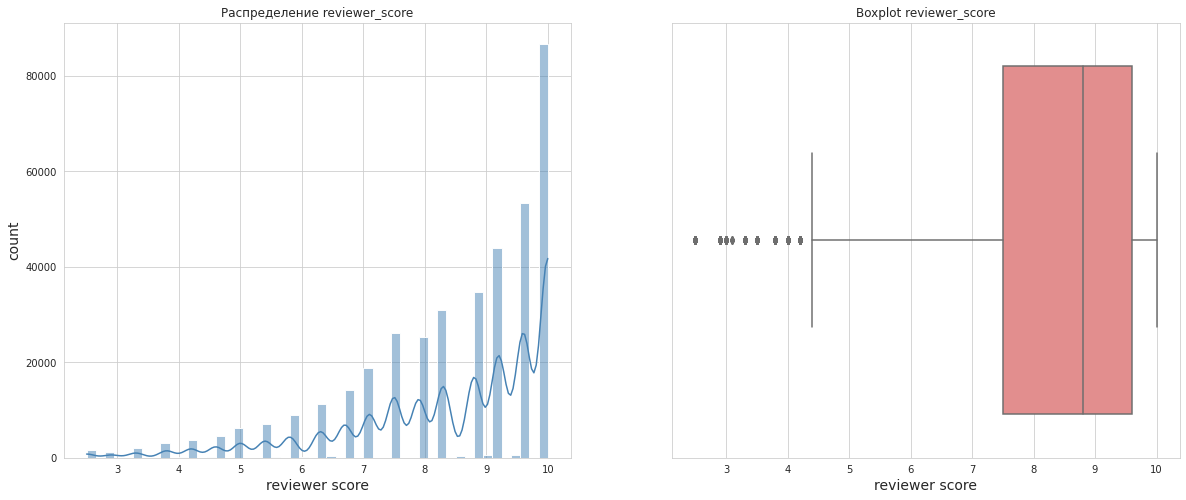

In [25]:
# Смотрим распределение целевой переменной
target = df_train['reviewer_score']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.histplot(target,
             bins=50,
             kde=True,
             ax=axes[0],
             color='steelblue'
)
axes[0].set_title('Распределение reviewer_score')
axes[0].set_xlabel('reviewer score', fontsize=14) 
axes[0].set_ylabel('count', fontsize=14)

sns.boxplot(x=target, ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot reviewer_score')
axes[1].set_xlabel('reviewer score', fontsize=14)

print(target.describe().to_string())

plt.show()

Визуально распределение не является нормальным,оно смещено в сторону высоких значений.

#### Проверка нормальности (на сэмпле) Shapiro-Wilk

In [26]:
# Фильтруем только обучающую выборку
train_target = data.loc[data['is_train'] == 1, 'reviewer_score']

# Для Shapiro-Wilk теста выбираем случайную выборку из 5000 элементов 
sample_for_shapiro = train_target.sample(min(5000, len(train_target)), random_state=RANDOM_SEED)

# Shapiro-Wilk тест
sh_stat, sh_p = stats.shapiro(sample_for_shapiro)
print(f"Shapiro-Wilk: stat={sh_stat:.4f}, p={sh_p:.2e}")

Shapiro-Wilk: stat=0.8603, p=0.00e+00


Тест Shapiro–Wilk показывает, что распределение reviewer_score не является нормальным: значение статистики далеко от 1, а p-value крайне мало, поэтому нулевая гипотеза о нормальности отклоняется

#### Распределение по месяцам

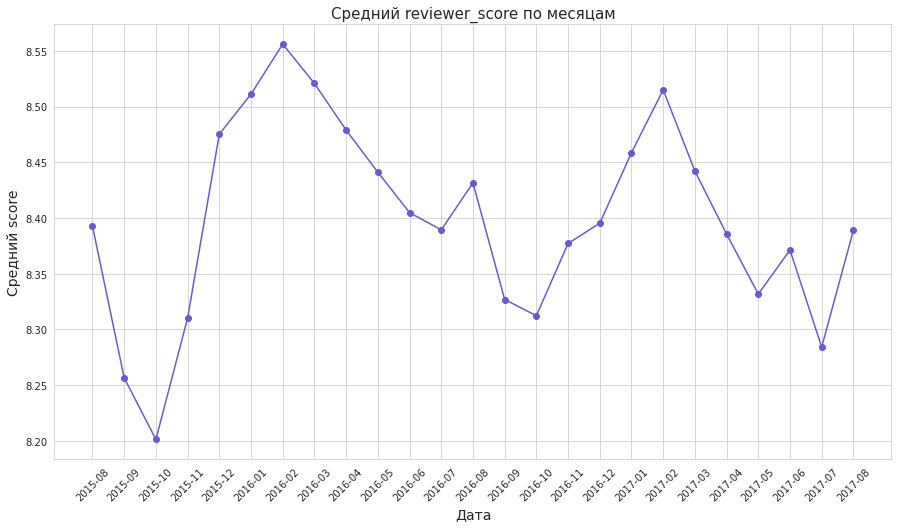

In [27]:
dt = pd.to_datetime(df_train['review_date'], errors='coerce') # на обучающей выборке
monthly = df_train.groupby(dt.dt.to_period('M'))['reviewer_score'].mean()
monthly.index = monthly.index.astype(str)

monthly.plot(kind='line',
             marker='o',
             color='slateblue'
)

plt.title('Средний reviewer_score по месяцам', fontsize=15)
plt.xticks(rotation=45)
# Показываем все подписи
plt.xticks(ticks=range(len(monthly.index)),
           labels=monthly.index,
           rotation=45
)
plt.ylabel('Средний score', fontsize=14)
plt.xlabel('Дата', fontsize=14)

plt.show()

Визуально есть зависимость между оценкой и месяцем, в котором отзыв был оставлен

### Топ стран по количеству отзывов

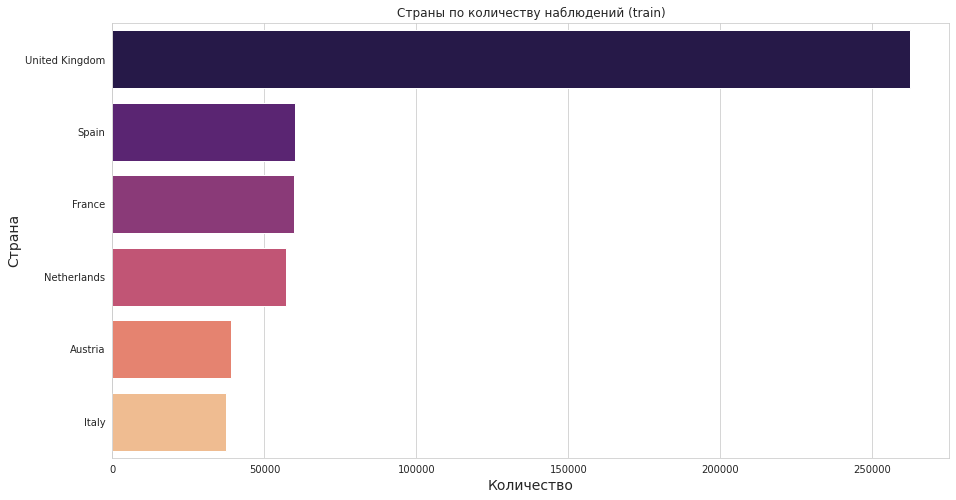

In [28]:
address = data['hotel_address'].astype(str)

def extract_country(address):
    parts = address.split()
    # UK — особый случай
    if 'United' in parts and 'Kingdom' in parts:
        return 'United Kingdom'
    return parts[-1]
    
country = address.map(extract_country)
countries = country.value_counts()
sns.barplot(x=countries.values, y=countries.index, palette='magma')
plt.title('Страны по количеству наблюдений (train)')
plt.xlabel('Количество', fontsize=14)
plt.ylabel('Страна', fontsize=14)

plt.show()

In [29]:
# Функция для извлечения города из адреса, временная функция для определения количества уникальных городов
def extract_city_temp(address):
    """
    Извлекает название города из строки адреса.
    По умолчанию город определяется как второе слово с конца адреса.
    Для адресов в Великобритании (оканчивается на 'United Kingdom')
    город принудительно устанавливается как 'London'.
    """
    parts = address.split()
    # Если последнее слово "Kingdom", считаем городом London
    if parts[-1] == "Kingdom":
        return "London"
    else:
        # Иначе берём второе слово с конца как город
        return parts[-2]

# Применяем к столбцу hotel_address и создаём новый столбец city
data['city'] = data['hotel_address'].apply(extract_city_temp)

# Проверим результат
print(data[['hotel_address', 'city']].sample(10))

# Посчитаем количество уникальных городов
print("Количество уникальных городов:", data['city'].nunique())

                                                                                  hotel_address       city
294537                          265 Rotherhithe Street Southwark London SE16 5HW United Kingdom     London
193199                                               C rsega 289 Eixample 08008 Barcelona Spain  Barcelona
222918           Scarsdale Place Kensington Kensington and Chelsea London W8 5SY United Kingdom     London
163850                    78 84 Sussex Gardens Westminster Borough London W2 1UH United Kingdom     London
129978                                      F hrichgasse 10 01 Innere Stadt 1010 Vienna Austria     Vienna
110996                 97 Great Russell Street Bloomsbury Camden London WC1B 3LB United Kingdom     London
91708   8 Balderton Street Brown Hart Gardens Westminster Borough London W1K 6TF United Kingdom     London
233421                     2 Wallenberg Place Westminster Borough London W1H 7TN United Kingdom     London
368022           Scarsdale Place Kens

In [30]:
# Анализируем полученный результат, интересует список уникальных городов
unique_cities = data['city'].unique()
print(unique_cities)

['Milan' 'Amsterdam' 'Barcelona' 'London' 'Paris' 'Vienna']


Так как уникальных городов всего 6, найдем координаты "центра города" в интернете, сделаем список и затем заполним дата сет, далее вычислим расстояние от отеля до центра города в км, создадим соответствующий признак

In [31]:
CITY_CENTERS = {
    "london": (51.5074, -0.1278),
    "paris": (48.8566, 2.3522),
    "amsterdam": (52.3676, 4.9041),
    "milan": (45.4642, 9.19),
    "vienna": (48.2082, 16.3738),
    "barcelona": (41.3851, 2.1734),
}

def extract_city(addr):
    addr = str(addr).lower()
    for city in CITY_CENTERS:
        if city in addr:
            return city
    return "unknown"
# функция для нахождения расстояния
# от отеля до центра
def distance_to_center(row):
    city = row['city']
    if city == "unknown" or pd.isna(row['lat']) or pd.isna(row['lng']):
        return 0.0
    lat0, lon0 = CITY_CENTERS[city]
    _, _, dist = GEOD.inv(lon0, lat0, row['lng'], row['lat'])
    return dist / 1000
# создаем признак города и расстояния до центра
data['city'] = data['hotel_address'].map(extract_city)
data['distance_to_city_center_km'] = data.apply(distance_to_center, axis=1)

In [32]:
data.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,is_train,reviewer_score,city,distance_to_city_center_km
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel that sold drinking water etc but not necessity Would recommend if like us you arrive late at night to bring drinks from plane airport as there s no shop nearby There is a minibar though if you want to pay those prices,52,16670,Hotel was great clean friendly staff free breakfast every morning with good selection good wifi connection nice sized room with bath fridge in room Personally loved the fact that the hotel isn t in the city centre but is literally next to a train station that you can easily get to and from the airport city Would definitely stay again,62,1,"[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 2 nights ']",13 days,45.533137,9.171102,0,NaN,milan,7.802865
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Netherlands,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ', ' Stayed 1 night ']",234 day,52.385649,4.834443,0,NaN,amsterdam,5.151317


#### Распределение по городам

              count      mean       std  min  25%  50%  75%   max
city                                                             
amsterdam   43004.0  8.449142  1.604043  2.5  7.5  8.8  9.6  10.0
barcelona   45132.0  8.553747  1.555254  2.5  7.9  9.2  9.6  10.0
london     196773.0  8.326877  1.669873  2.5  7.5  8.8  9.6  10.0
milan       27882.0  8.355541  1.639415  2.5  7.5  8.8  9.6  10.0
paris       44528.0  8.424248  1.651530  2.5  7.5  8.8  9.6  10.0
vienna      29177.0  8.552593  1.507061  2.5  7.9  9.2  9.6  10.0


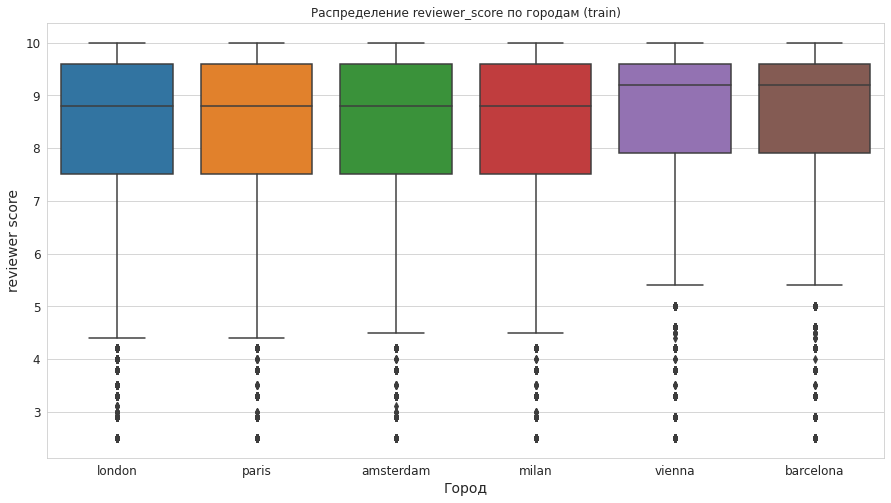

In [33]:
# Фильтруем только тренировочные данные
train = data[data['is_train'] == 1]
# статистика
print(train.groupby('city')['reviewer_score'].describe())

sns.boxplot(data=train,
            x='city',
            y='reviewer_score'
)

plt.title('Распределение reviewer_score по городам (train)')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Город', fontsize=14)
plt.ylabel('reviewer score', fontsize=14)

plt.show()

#### Зависимость reviewer score от расстояния до центра

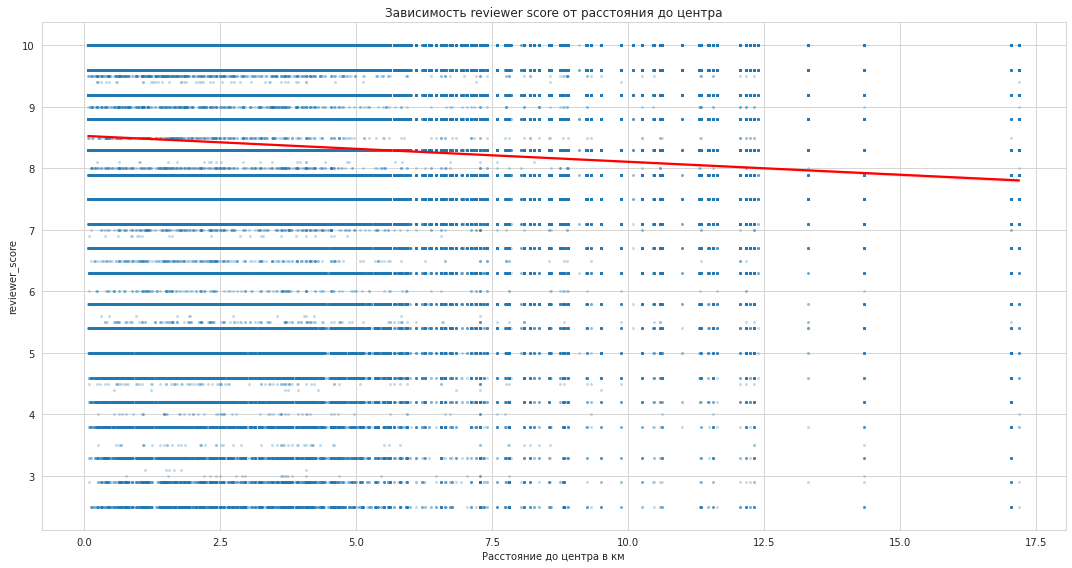

Корреляция distance_to_city_center_km с reviewer_score: -0.066


In [34]:
data_train = data[data['is_train'] == 1].copy()
col = 'distance_to_city_center_km'  

sns.regplot(
    x=data_train[col],
    y=data_train['reviewer_score'],
    scatter_kws={'s':4, 'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title('Зависимость reviewer score от расстояния до центра')
plt.ylabel('reviewer_score')
plt.xlabel('Расстояние до центра в км')
plt.tight_layout()

plt.show()

corr_value = np.corrcoef(data_train[col], data_train['reviewer_score'])[0,1]
print(f'Корреляция {col} с reviewer_score: {corr_value:.3f}')

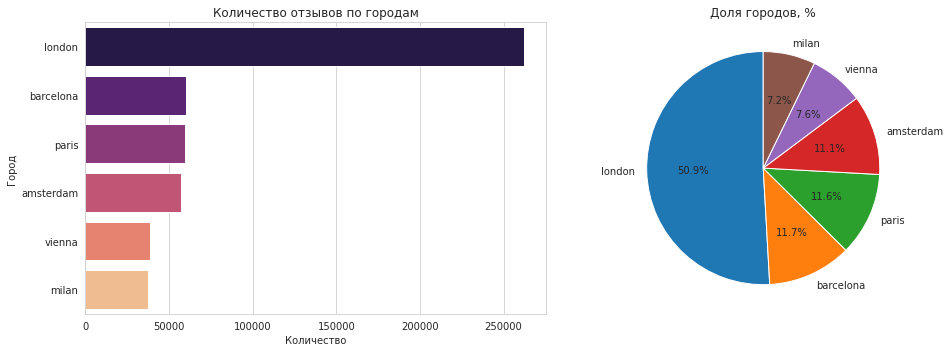

In [35]:
# Количество отзывов по городам
city_counts = data['city'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
sns.barplot(
    x=city_counts.values,
    y=city_counts.index,
    palette='magma',
    ax=axes[0]
)
axes[0].set_title('Количество отзывов по городам')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Город')

# Круговая диаграмма
axes[1].pie(
    city_counts.values,
    labels=city_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Доля городов, %')
plt.tight_layout()

plt.show()

#### Связь количества слов с оценкой

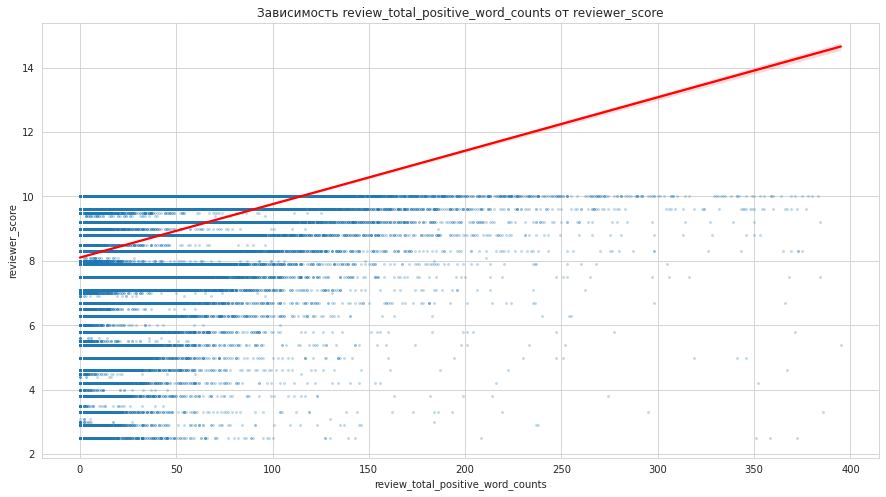

Корреляция review_total_positive_word_counts с reviewer_score: 0.220


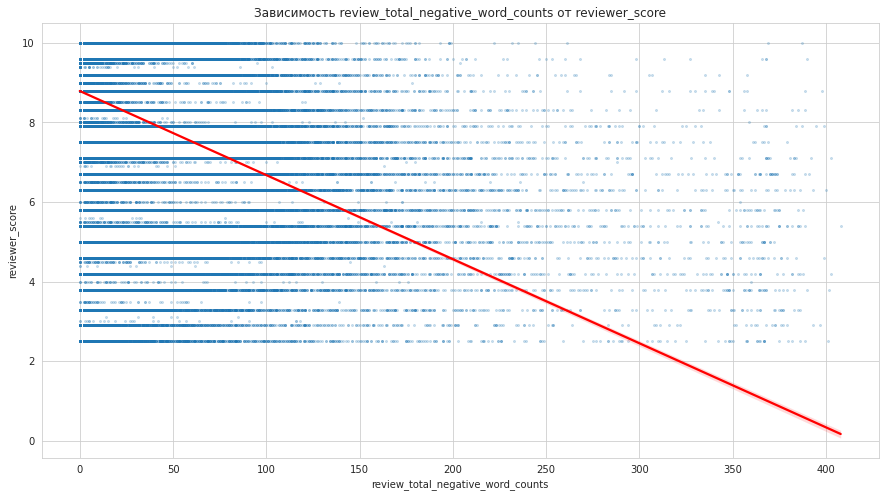

Корреляция review_total_negative_word_counts с reviewer_score: -0.383


In [36]:
for col in ['review_total_positive_word_counts', 'review_total_negative_word_counts']:
    sns.regplot(x=df_train[col],
                y=df_train['reviewer_score'],
                scatter_kws={'s':4, 'alpha':0.2},
                line_kws={'color':'red'}
               )
    plt.title(f'Зависимость {col} от reviewer_score')
    plt.show()
    corr_value = np.corrcoef(df_train[col], df_train['reviewer_score'])[0,1]
    print(f'Корреляция {col} с reviewer_score: {corr_value:.3f}')

review_total_positive_word_counts: корреляция 0.220 — слабая положительная связь, что чем больше позитивных слов в отзыве, тем чуть выше оценка, но эффект не очень сильный.

review_total_negative_word_counts: корреляция -0.383 — умеренная отрицательная связь, чем больше негативных слов, тем ниже оценка, и эта связь выражена сильнее, чем у количества позитивных слов.

## Feature Engineering

In [37]:
# Сумма позитивных и негативных слов
total_words = data['review_total_positive_word_counts'] + data['review_total_negative_word_counts']

# negative_word_ratio — доля негативных слов (без деления на ноль)
data['negative_word_ratio'] = data['review_total_negative_word_counts'] / total_words.replace(0, 1)

# positive_word_ratio — доля позитивных слов
data['positive_word_ratio'] = 1 - data['negative_word_ratio']

negative_word_ratio — доля негативных слов в отзыве (negative / (positive + negative)), отражает тональность отзыва  
positive_word_ratio — доля позитивных слов (1 - negative_word_ratio), отражает позитивную окраску отзыва

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 22 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [39]:
# Выделяем из столбца числовые значения
data['days_since_review'] = (
    data['days_since_review']
    .str.extract('(\d+)')
    .astype(int)
)

# Проверка
print(data['days_since_review'].head())

0     13
1    234
2    616
3    656
4    444
Name: days_since_review, dtype: int64


#### Создадим новые признаки из 'negative_review'

In [40]:
#преобразуем признак negative_review в список слов 
data['negative_review'] = data['negative_review'].apply(
    lambda x: x.lower().split()
)

data['negative_review'].head()

0    [would, have, appreciated, a, shop, in, the, hotel, that, sold, drinking, water, etc, but, not, necessity, would, recommend, if, like, us, you, arrive, late, at, night, to, bring, drinks, from, plane, airport, as, there, s, no, shop, nearby, there, is, a, minibar, though, if, you, want, to, pay, those, prices]
1                                                                                                                                                                                                                                                                      [no, tissue, paper, box, was, present, at, the, room]
2                                                                                                                                                                                                                                                                                                                  [pillows]
3                                                

In [41]:
# посмотрим наиболее часто встречающиеся слова, исключив из них слова 
# длиной 3 и менее символов, так как это в основном артикли, союзы, местоимения
df_negative = pd.DataFrame(
    data[data['review_total_negative_word_counts'] > 0]['negative_review'].explode()
)
df_negative['len'] = df_negative['negative_review'].apply(lambda x: len(str(x)))
df_negative[df_negative['len'] > 3]['negative_review'].value_counts().head(20) # посмотрим 20 самых популярных

room         175898
very          80545
hotel         74657
were          61654
that          58862
breakfast     58440
have          54681
with          51967
small         49857
there         46468
they          42606
from          40226
this          39667
staff         39490
nothing       38754
rooms         34782
would         32278
could         32061
when          30920
only          28024
Name: negative_review, dtype: int64

In [42]:
#заполним вручную список часто встречающихся слов в негативном отзыве
top_negative_words = [
    'room', 'very', 'hotel', 'breakfast', 'small', 'staff', 'nothing', 'rooms', 'only','would', 'could'
]

In [43]:
#создадим признаки для наиболее часто встречающихся слов в негативных отзывах
for negative_word in top_negative_words:
    data['negative_'+ negative_word] = data['negative_review'].apply(
        lambda x: 1 if negative_word in x else 0
    )
# проверка
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 33 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

#### Создадим новые признаки из признака 'positive_reviw'

In [44]:
#преобразуем признак positive_review в список слов 
data['positive_review'] = data['positive_review'].apply(
    lambda x: x.lower().split()
)

data['positive_review'].head()

0    [hotel, was, great, clean, friendly, staff, free, breakfast, every, morning, with, good, selection, good, wifi, connection, nice, sized, room, with, bath, fridge, in, room, personally, loved, the, fact, that, the, hotel, isn, t, in, the, city, centre, but, is, literally, next, to, a, train, station, that, you, can, easily, get, to, and, from, the, airport, city, would, definitely, stay, again]
1                                                                                                                                                                                                                                                                                                                                                                                                  [no, positive]
2                                                                                                                                                                                                   

In [45]:
# Смотрим часто встречающиеся слова
df_positive = pd.DataFrame(
    data[data['review_total_positive_word_counts'] > 0]['positive_review'].explode()
)
df_positive['len'] = df_positive['positive_review'].apply(lambda x: len(str(x)))
df_positive[df_positive['len'] > 3]['positive_review'].value_counts().head(20)

staff          194472
location       192730
very           192630
room           140673
hotel          125259
good           112262
great          105571
were            90823
friendly        85308
breakfast       84551
helpful         76145
nice            69408
clean           66890
with            65883
excellent       62242
comfortable     59929
from            43758
rooms           40345
lovely          35083
stay            32018
Name: positive_review, dtype: int64

In [46]:
top_positive_words = ['staff', 'location', 'room', 'hotel' , 'breakfast', 'rooms' 
    'nice', 'clean', 'very', 'excellent', 'comfortable', 'good', 
    'great', 'friendly', 'lovely','helpful'
]

In [47]:
#создадим признаки для наиболее часто встречающихся слов в позитивном отзыве
for positive_word in top_positive_words:
    data['positive_'+ positive_word] = data['positive_review'].apply(
        lambda x: 1 if positive_word in x else 0
    )
# Проверка
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 48 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [48]:
# Переводим столбец с датой в datetime
data['review_date'] = pd.to_datetime(data['review_date'])
data['year'] = data['review_date'].dt.year
data['month'] = data['review_date'].dt.month

data = data.drop(columns=['review_date']) # удаляем

#### Обработаем теги

In [49]:
# Если tags не список (например, строка), преобразуем в список
if isinstance(data.tags.iloc[0], str):
    data.tags = data.tags.apply(lambda x: x[3:-3].split(" ', ' "))

# разворачиваем список тегов в столбец 
all_tags = data.tags.explode()

# Считаем количество каждого тега
tag_counts = all_tags.value_counts()

# Сколько уникальных тегов
num_unique_tags = tag_counts.shape[0]
print("Количество уникальных тегов:", num_unique_tags)

# Какой тег представлен в наибольшем числе отзывов
most_common_tag = tag_counts.idxmax()
print("Самый популярный тег:", most_common_tag)

# Берём топ-10
top_10_tags = tag_counts.head(10)

# Находим долю топ-10
top_10_tags_percent = (top_10_tags / len(data) * 100).round(2)

# Вывод в виде таблицы
top_10_table = pd.DataFrame({
    'Tag': top_10_tags.index,
    'Count': top_10_tags.values,
    'Percent': top_10_tags_percent.values}
)

print(top_10_table)

Количество уникальных тегов: 2428
Самый популярный тег: Leisure trip
                              Tag   Count  Percent
0                    Leisure trip  417538    81.01
1  Submitted from a mobile device  307470    59.65
2                          Couple  252128    48.92
3                  Stayed 1 night  193568    37.55
4                 Stayed 2 nights  133850    25.97
5                   Solo traveler  108476    21.05
6                 Stayed 3 nights   95761    18.58
7                   Business trip   82884    16.08
8                           Group   65361    12.68
9      Family with young children   60989    11.83


Leisure trip встречается в 81% отзывов — большинство гостей путешествовали ради отдыха.

Submitted from a mobile device — 60% отзывов с мобильных устройств, что показывает, что пользователи активно оставляют отзывы с телефонов.

Тип путешествия гостей - Couple — 49%, Solo traveler — 21%, Group — 13%, Family with young children — 12%. Большинство гостей — пары и отдыхающие в одиночку, семейные поездки реже.

Business trip — 16%, то есть командировочных поездок меньше, чем туристов.

Продолжительность проживания - Stayed 1 night — 38%, Stayed 2 nights — 26%, Stayed 3 nights — 19%. Большинство гостей останавливаются на 1–2 ночи, длинные пребывания редки.

Анализ тегов показывает, что отели в этом датасете в основном посещают туристы для отдыха (пары и одиночки), которые остаются на короткий срок, и что мобильные устройства активно используются для оставления отзывов.

In [50]:
# Топ-10 тегов
top_tags = ['Leisure trip', 'Submitted from a mobile device', 'Couple',
            'Stayed 1 night', 'Stayed 2 nights', 'Stayed 3 nights',
            'Solo traveler', 'Business trip', 'Group', 'Family with young children']

# Создаём бинарные столбцы для популярных тегов
for tag in top_tags:
    col_name = f'tag_{tag.replace(" ", "_")}'
    data[col_name] = data['tags'].apply(lambda x: int(tag in x))

# Признак количество тегов на отзыв
data['num_tags'] = data['tags'].apply(len)

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 60 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   average_score                               515431 non-null  float64
 3   hotel_name                                  515431 non-null  object 
 4   reviewer_nationality                        515431 non-null  object 
 5   negative_review                             515431 non-null  object 
 6   review_total_negative_word_counts           515431 non-null  int64  
 7   total_number_of_reviews                     515431 non-null  int64  
 8   positive_review                             515431 non-null  object 
 9   review_total_positive_word_counts           515431 non-null  int64  
 

In [52]:
# Создадим признак количества ночей
data['nights'] = (data['tags']
                  .str.join(' ')
                  .str.extract(r'Stayed (\d+) nights?', flags=re.IGNORECASE, expand=False)
                  .astype(float)
                  .fillna(1)    
                  .astype(int)
)

In [53]:
# проверка
data['nights'].unique()

array([ 2,  1,  3,  4,  7,  5,  6, 14, 12,  8,  9, 13, 10, 11, 18, 16, 25,
       15, 19, 23, 26, 17, 21, 24, 29, 20, 22, 31, 27, 30, 28])

#### Признак национальности; закодируем по средней оценке каждой национальности

In [54]:
# Выделяем обучающую выборку
train_data = data[data['is_train'] == 1]

# Считаем среднее по национальностям на обучающей выборке
foreigner_means = train_data.groupby('reviewer_nationality')['reviewer_score'].mean()

# Считаем глобальное среднее (на случай, если в тесте будет новая национальность)
global_mean = train_data['reviewer_score'].mean()

# Применяем кодирование ко всему датасету
data['nationality_encoded'] = data['reviewer_nationality'].map(foreigner_means)

# если для каких-то строк в тесте map вернул NaN,
# заполняем их глобальным средним числом
data['nationality_encoded'] = data['nationality_encoded'].fillna(global_mean)

#### Закодируем "Город" методом порядкового кодирования

In [55]:
# Задаем четкий список всех возможных городов
city_list = ['london', 'paris', 'amsterdam', 'milan', 'vienna', 'barcelona']

# Переводим в категорию по списку
data['city'] = pd.Categorical(data['city'], categories=city_list)
# Создаем новый признак закодированных городов
data['city_code'] = data['city'].cat.codes

data = data.drop(columns=['city']) # удаляем 

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 62 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   average_score                               515431 non-null  float64
 3   hotel_name                                  515431 non-null  object 
 4   reviewer_nationality                        515431 non-null  object 
 5   negative_review                             515431 non-null  object 
 6   review_total_negative_word_counts           515431 non-null  int64  
 7   total_number_of_reviews                     515431 non-null  int64  
 8   positive_review                             515431 non-null  object 
 9   review_total_positive_word_counts           515431 non-null  int64  
 

### Анализ мультиколлинеарности

In [57]:
# убираем нечисловые признаки, которые мы уже обработали
# модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
object_columns = [s for s in data.columns if data[s].dtypes == 'object']
data.drop(object_columns, axis = 1, inplace=True)

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 56 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                515431 non-null  int64  
 1   average_score                               515431 non-null  float64
 2   review_total_negative_word_counts           515431 non-null  int64  
 3   total_number_of_reviews                     515431 non-null  int64  
 4   review_total_positive_word_counts           515431 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  515431 non-null  int64  
 6   days_since_review                           515431 non-null  int64  
 7   lat                                         515431 non-null  float64
 8   lng                                         515431 non-null  float64
 9   is_train                                    515431 non-null  int64  
 

#### Корреляция Спирмена

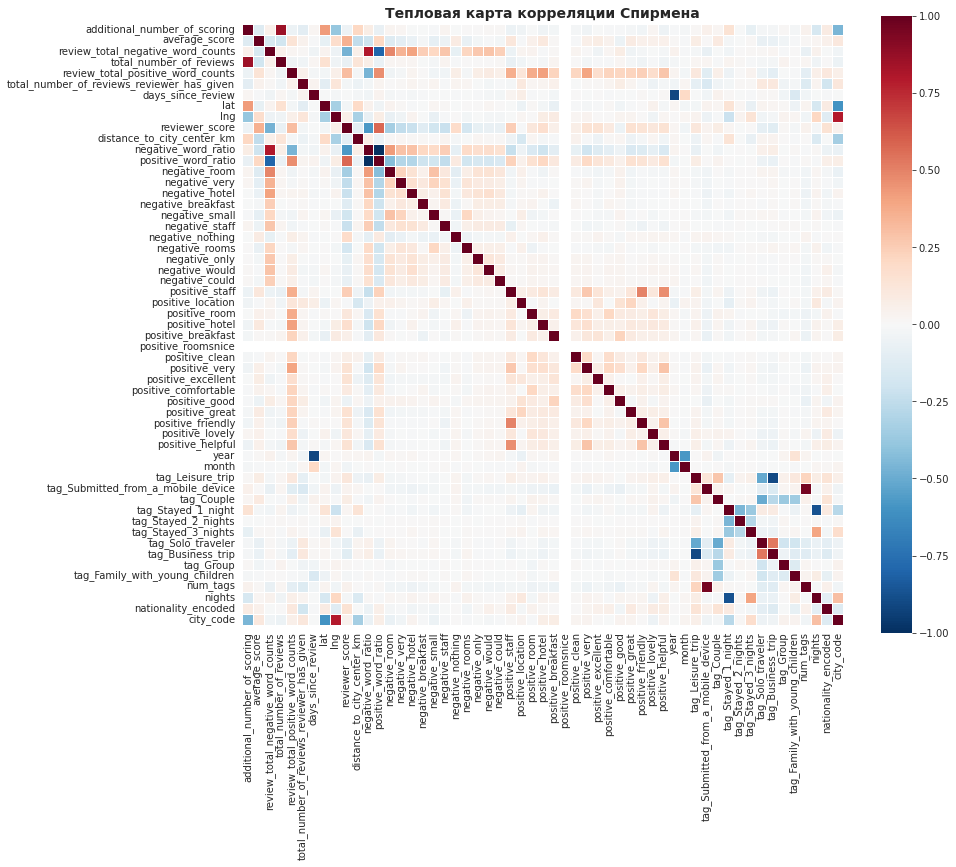

In [59]:
# Корреляционная матрица
corr_matrix = data.drop(['is_train'], axis=1).corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_matrix, 
            # annot=True, 
            # fmt='.2f',
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            square=True, 
            ax=ax,
            linewidths=0.5
            # annot_kws={'size': 8}
)

ax.set_title('Тепловая карта корреляции Спирмена', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

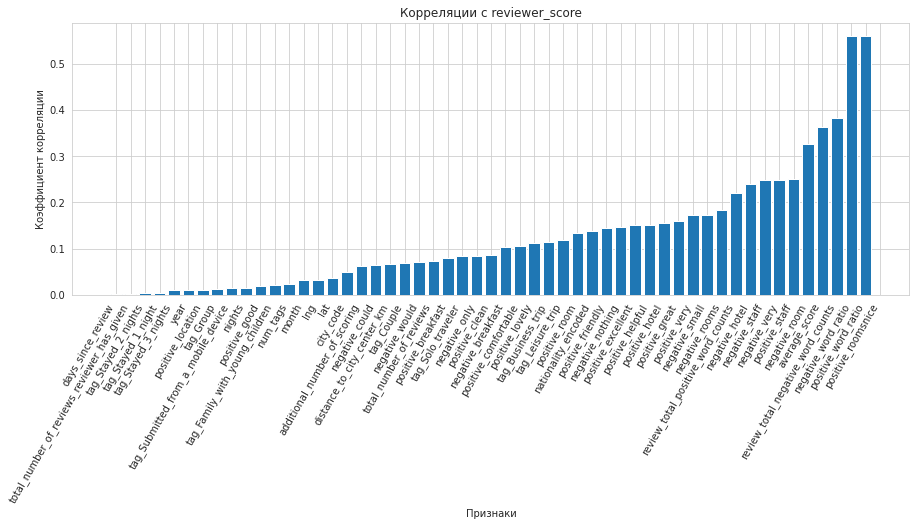

In [60]:
# Вычисляем модуль корреляции с целевой переменной
corr_with_target = data.drop(['is_train'], axis=1).corr()['reviewer_score'].abs().sort_values()
# Удаляем корреляцию целевой переменной с собой же
corr_with_target = corr_with_target.drop('reviewer_score')
# Строим столбчатую диаграмму корреляций
fig, ax = plt.subplots(figsize=(15, 5)) 
ax.bar(corr_with_target.index, corr_with_target.values)
ax.set_title('Корреляции с reviewer_score')
ax.set_xlabel('Признаки')
ax.set_ylabel('Коэффициент корреляции')

ax.tick_params(axis='x', labelrotation=60)
for label in ax.get_xticklabels():
    label.set_horizontalalignment('right')

plt.show()

In [61]:
# Удалим ненужные столбцы с высокой корреляцией
columns_to_drop = ['additional_number_of_scoring', 'year', 'tag_Submitted_from_a_mobile_device', 'tag_Business_trip', 'tag_Stayed_1_night']
data = data.drop(columns=columns_to_drop)

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 51 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               515431 non-null  float64
 1   review_total_negative_word_counts           515431 non-null  int64  
 2   total_number_of_reviews                     515431 non-null  int64  
 3   review_total_positive_word_counts           515431 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  515431 non-null  int64  
 5   days_since_review                           515431 non-null  int64  
 6   lat                                         515431 non-null  float64
 7   lng                                         515431 non-null  float64
 8   is_train                                    515431 non-null  int64  
 9   reviewer_score                              386496 non-null  float64
 

## Разделение данных

In [63]:
# Разделение train / test + проверки
train_data = data.query('is_train == 1')
test_data  = data.query('is_train == 0')

print("TRAIN:", len(train_data))
print("TEST :", len(test_data))
print("TOTAL:", len(data))

# Контроль целостности
assert len(train_data) + len(test_data) == len(data), " Потеря строк"
assert train_data["reviewer_score"].notna().all(), " NaN в target train"
assert test_data["reviewer_score"].isna().all(),  " Target не должен быть в test"

# 3. И только ПОСЛЕ проверок удаляем ненужные столбцы
train_data = train_data.drop(['is_train'], axis=1)
# Из теста удаляем и маркер train, и пустой столбец таргета
test_data  = test_data.drop(['is_train'], axis=1)

print("✔ train/test разделены корректно")

TRAIN: 386496
TEST : 128935
TOTAL: 515431
✔ train/test разделены корректно


In [64]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 128935 entries, 0 to 128934
Data columns (total 50 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               128935 non-null  float64
 1   review_total_negative_word_counts           128935 non-null  int64  
 2   total_number_of_reviews                     128935 non-null  int64  
 3   review_total_positive_word_counts           128935 non-null  int64  
 4   total_number_of_reviews_reviewer_has_given  128935 non-null  int64  
 5   days_since_review                           128935 non-null  int64  
 6   lat                                         128935 non-null  float64
 7   lng                                         128935 non-null  float64
 8   reviewer_score                              0 non-null       float64
 9   distance_to_city_center_km                  128935 non-null  float64
 

In [65]:
test_data.isnull().sum()

average_score                                      0
review_total_negative_word_counts                  0
total_number_of_reviews                            0
review_total_positive_word_counts                  0
total_number_of_reviews_reviewer_has_given         0
days_since_review                                  0
lat                                                0
lng                                                0
reviewer_score                                128935
distance_to_city_center_km                         0
negative_word_ratio                                0
positive_word_ratio                                0
negative_room                                      0
negative_very                                      0
negative_hotel                                     0
negative_breakfast                                 0
negative_small                                     0
negative_staff                                     0
negative_nothing                              

In [66]:
y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

In [67]:
# Воспользуемся специальной функцией train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [68]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 50), (386496, 50), (386496, 49), (309196, 49), (77300, 49))

## Обучение модели

In [69]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [70]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [71]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.5min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.8s finished


In [72]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
# ручная формула MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAE: 0.8808180860592617
MAPE: 12.73%


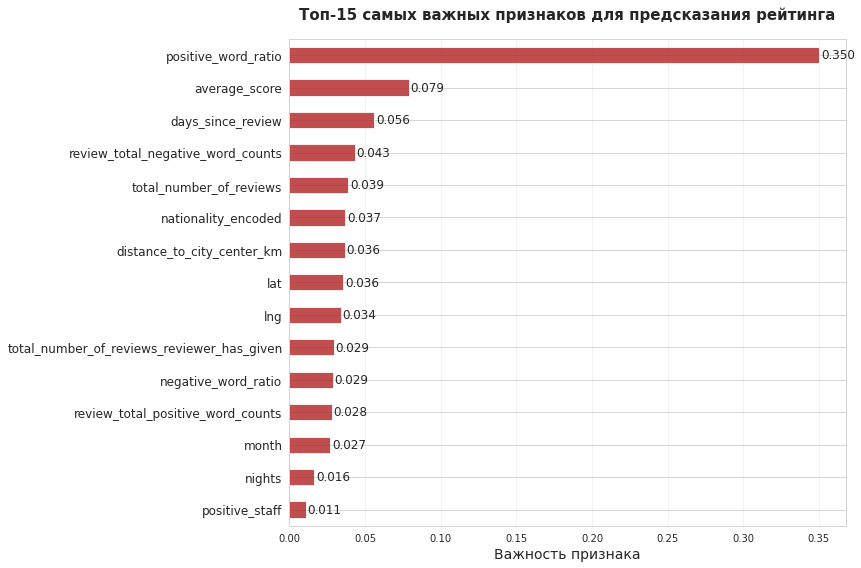

In [73]:
# Получаем важность признаков
feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)

# Топ-15 самых важных признаков
top_10_features = feat_importances.nlargest(15)

fig, ax = plt.subplots(figsize=(12, 8))
# Строим горизонтальную диаграмму
bars = top_10_features.plot(kind='barh',
                            ax=ax,
                            color='firebrick',
                            alpha=0.8
                        )

ax.set_title('Топ-15 самых важных признаков для предсказания рейтинга', 
             fontsize=15,
             fontweight='bold',
             pad=20
)
ax.set_xlabel('Важность признака', fontsize=14)

# Добавляем значения на график
for i, (feature, importance) in enumerate(top_10_features.items()):
    ax.text(importance + 0.001, i, f'{importance:.3f}', 
            va='center', ha='left', fontsize=12)

# Улучшаем сетку и подписи
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=12)

# Инвертируем ось Y, чтобы самый важный признак был сверху
ax.invert_yaxis()

plt.tight_layout()

plt.show()

In [74]:
test_data.sample(10)

,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,reviewer_score,distance_to_city_center_km,...,tag_Couple,tag_Stayed_2_nights,tag_Stayed_3_nights,tag_Solo_traveler,tag_Group,tag_Family_with_young_children,num_tags,nights,nationality_encoded,city_code
71526,8.5,0,7586,6,2,667,52.385601,4.847060,NaN,4.370494,...,0,1,0,0,1,0,4,2,8.488676,2
21068,9.2,0,1772,23,1,399,48.207235,16.372238,NaN,0.158104,...,1,0,1,0,0,0,4,3,8.700163,4
51873,8.4,34,1494,14,1,514,51.511521,-0.290706,NaN,11.319222,...,1,1,0,0,0,0,5,2,8.488676,0
37713,8.5,0,1354,5,13,24,41.392710,2.172214,NaN,0.850991,...,0,1,0,0,0,1,4,2,8.700163,5
31372,7.5,6,2092,3,48,497,51.517839,-0.142448,NaN,1.543664,...,0,0,0,1,0,0,4,1,8.488676,0
128159,8.3,2,1640,14,7,143,51.542148,-0.170307,NaN,4.863013,...,0,0,0,0,1,0,5,1,8.488676,0
52277,9.3,34,1694,41,1,480,51.508236,-0.126196,NaN,0.145081,...,1,0,0,0,0,0,5,4,8.488676,0
5152,8.2,40,775,58,37,297,45.483717,9.164937,NaN,2.923356,...,1,0,1,0,0,0,4,3,8.229278,3
44784,8.4,95,2726,74,3,59,51.507377,0.038657,NaN,11.556989,...,0,0,0,0,1,0,4,1,8.488676,0
119339,7.9,0,564,3,7,157,51.508202,-0.154559,NaN,1.859976,...,0,0,0,1,0,0,5,5,8.034595,0


In [75]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [76]:
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [77]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.7s finished


In [78]:
# Проверим размеры данных
print("Проверка размеров данных:")
print(f"test_data.shape: {test_data.shape}")
print(f"sample_submission.shape: {sample_submission.shape}")

# Проверим, есть ли NaN в test_data
print(f"NaN в test_data: {test_data.isnull().sum().sum()}")

# Проверим размер предсказаний
print(f"Размер predict_submission: {len(predict_submission)}")

Проверка размеров данных:
test_data.shape: (128935, 49)
sample_submission.shape: (128935, 2)
NaN в test_data: 0
Размер predict_submission: 128935


In [79]:
predict_submission

array([8.831, 6.529, 8.049, ..., 8.071, 9.624, 6.592])

In [80]:
sample_submission['reviewer_score'] = predict_submission

sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.831,488440
1,6.529,274649
2,8.049,374688
3,9.527,404352
4,9.584,451596
5,8.709,302161
6,8.068,317079
7,7.801,13963
8,8.903,159785
9,7.929,195089


Создана рабочая модель предсказания рейтингов отелей с MAPE = 12.8, способная выявлять потенциально нечестные отели с точностью выше базового уровня (MAPE = 14.1).